Импорт нужных библиотек:
- Requests для осуществления запросов к созданному API
- MatPlotLib для реализации графиков
- Plotly.express для отображения информации на карте
- Pandas для обработки информации

In [1]:
from matplotlib import pyplot as plt
import requests

import plotly.express as px
import pandas as pd

from NNTouristsAPI.routers.general import avg_values

1. Сколько туристов посетило Нижний Новгород за весь диапазон дат, представленных в выборке (2022 год);

In [3]:
url = "http://127.0.0.1:2137/count_sort/month"

response = requests.get(url)

if response.status_code == 200:
    data = response.json()
else:
    data = {}

print(data)

[{'name': '2022-01', 'count': 74361, 'average': 44525.387411277414}, {'name': '2022-02', 'count': 65859, 'average': 56435.08634309661}, {'name': '2022-03', 'count': 76738, 'average': 49814.096047199564}, {'name': '2022-04', 'count': 78978, 'average': 48721.3732876244}, {'name': '2022-05', 'count': 91098, 'average': 50803.00108783947}, {'name': '2022-06', 'count': 104366, 'average': 50804.99278596478}, {'name': '2022-07', 'count': 125337, 'average': 47264.22487600318}, {'name': '2022-08', 'count': 124842, 'average': 47609.12424973183}, {'name': '2022-09', 'count': 89240, 'average': 47659.88192114776}, {'name': '2022-10', 'count': 86303, 'average': 48283.92891122825}, {'name': '2022-11', 'count': 79788, 'average': 46313.49254879681}, {'name': '2022-12', 'count': 82267, 'average': 44059.52209947528}]


Для получения ответа на этот вопрос, нужно сложить все значения количества туристов, что посещали Нижний Новгород каждый месяц

In [4]:
print(sum([i["count"] for i in data]))

1079177


2. Сколько туристов посещало Нижний Новгород каждый месяц;

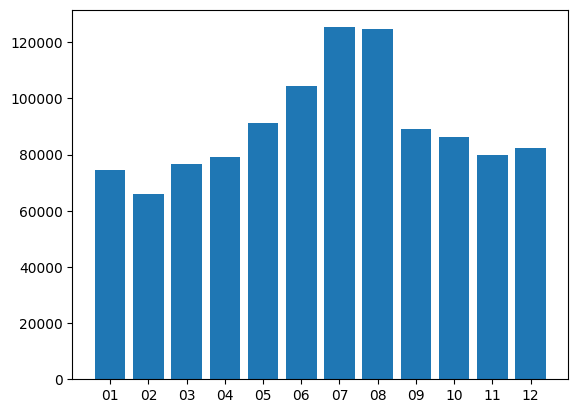

In [5]:
plt.bar([i["name"][5:] for i in data], [i["count"] for i in data])
plt.show()

3. Как представлено территориальное распределение туристов (откуда они приехали - страны, регионы, районы);

In [6]:
home_country_url = "http://127.0.0.1:2137/count_sort_geo/home_country"

home_country_response = requests.get(home_country_url)

if home_country_response.status_code == 200:
    home_country_data = home_country_response.json()
else:
    home_country_data = {}

print(home_country_data)

[{'name': 'Австралия', 'count': 4, 'latitude': -25.2744, 'longitude': 133.7751}, {'name': 'Австрия', 'count': 31, 'latitude': 47.5162, 'longitude': 14.5501}, {'name': 'Азербайджан', 'count': 406, 'latitude': 40.1431, 'longitude': 47.5769}, {'name': 'Албания', 'count': 6, 'latitude': 41.1533, 'longitude': 19.5046}, {'name': 'Алжир', 'count': 19, 'latitude': 28.0339, 'longitude': 1.6596}, {'name': 'Ангола', 'count': 7, 'latitude': -11.2027, 'longitude': 17.8739}, {'name': 'Армения', 'count': 128, 'latitude': 40.0691, 'longitude': 45.0382}, {'name': 'Бахрейн', 'count': 1, 'latitude': 26.0667, 'longitude': 50.5577}, {'name': 'Белоруссия', 'count': 924, 'latitude': 53.7098, 'longitude': 27.9534}, {'name': 'Бельгия', 'count': 17, 'latitude': 50.5039, 'longitude': 4.4699}, {'name': 'Болгария', 'count': 41, 'latitude': 42.7339, 'longitude': 25.4858}, {'name': 'Босния и Герцеговина', 'count': 9, 'latitude': 43.9159, 'longitude': 17.6791}, {'name': 'Бразилия', 'count': 1, 'latitude': -14.235, 'l

In [7]:
df = {"name": [i["name"] for i in home_country_data], "count": [i["count"] for i in home_country_data]}

# Координаты центров стран (получены из интернета)
df['lat'] = [-25.2744, 47.5162, 40.1431, 41.1533, 28.0339, -11.2027, 40.0691, 26.0667, 53.7098, 50.5039, 42.7339, 43.9159, -14.235, 55.3781, 47.1625, 21.2802, 7.9465, 15.7835, 9.9459, 51.1657, 22.3964, 39.0742, 42.3154, 56.2639, 26.8206, 31.0461, 20.5937, -0.7893, 31.2156, 33.2232, 32.4279, 53.4129, 64.9631, 40.4637, 41.8719, 48.0196, 7.3699, 56.1304, 25.3548, 35.1264, 41.2044, 35.8617, 23.6978, 4.5709, 7.54, 29.3117, 56.8796, 33.8547, 55.1694, 49.8153, -20.3484, 4.2105, 35.9375, 31.7917, 23.6345, 46.8625, 46.8625, 21.9162, 9.082, 52.1326, 60.472, 23.4241, 21.4733, 30.3753, 51.9194, 39.3999, 35.9078, 61.524, 45.9432, 23.8859, 41.6086, -4.6796, 14.4974, 44.0165, 1.3521, 34.8021, 48.669, 46.1512, 12.8628, 37.0902, 38.861, 15.87, -6.369, 33.8869, 38.9697, 38.9637, 1.3733, 41.3775, 48.3794, -32.5228, -17.7134, 12.8797, 61.9241, 46.2276, 45.1, 15.4542, 42.7087, 49.8175, -35.6751, 46.8182, 60.1282, 7.8731, -1.8312, 58.5953, -30.5595, 36.2048]

df['lon'] = [133.7751, 14.5501, 47.5769, 19.5046, 1.6596, 17.8739, 45.0382, 50.5577, 27.9534, 4.4699, 25.4858, 17.6791, -51.9253, -3.436, 19.5033, 105.8575, -1.0232, -85.3022, -9.9549, 10.4515, 114.1095, 21.8243, 43.3569, 9.5018, 30.8025, 34.8516, 78.9629, 113.9213, 36.0, 43.6793, 53.688, -7.9795, -19.0208, -3.7492, 12.5674, 66.0463, 12.3547, -106.3468, 51.1839, 33.4346, 74.7661, 104.1954, 110.7883, -74.2973, -5.5471, 47.4818, 24.6032, 35.8623, 23.8813, 6.1296, 57.5522, 101.9758, 14.3754, -7.0926, -102.5528, 27.4773, 103.8467, 95.956, 8.6753, 5.2913, 8.4689, 53.8478, 55.9755, 69.3451, 19.1451, -8.2245, 127.7669, 105.3188, 24.9668, 45.0792, 21.7453, 55.4919, -14.4524, 21.0059, 103.8198, 38.9968, 19.699, 14.9955, 30.2176, -95.7129, 71.2761, 100.9925, 34.8888, 9.5375, 59.5563, 35.2433, 32.2903, 64.5853, 31.1656, -55.7658, 178.065, 121.774, 25.7482, 2.2137, 15.2, 18.7322, 19.3744, 15.473, -71.543, 8.2275, 18.6435, 80.7718, -78.1834, 25.0136, 22.9375, 138.2529]

#Из-за того, что количество туристов из России, посетивших Нижний Новгород, в тысячи раз больше, чем туристов из других стран, для отображения точек будут проведены степенные преобразования
df['deg_count'] = [i["count"]**0.33 for i in home_country_data]
df = pd.DataFrame(df)

fig = px.scatter_mapbox(
    df, lat='lat', lon='lon',
    size='deg_count', size_max=25,
    hover_name='name',
    hover_data={'count': ':.0f', 'lat': False, 'lon': False, 'deg_count': ':.2f'},
    mapbox_style='carto-positron',
    zoom=1
)
fig.show()

C:\Users\Andrzej\AppData\Local\Temp\ipykernel_10544\1290554021.py:12: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [8]:
home_region_url = "http://127.0.0.1:2137/count_sort_geo/home_region"

home_region_response = requests.get(home_region_url)

if home_region_response.status_code == 200:
    home_region_data = home_region_response.json()
else:
    home_region_data = {}

print(home_region_data)

[{'name': 'Алтайский край', 'count': 418, 'latitude': 52.8, 'longitude': 82.9}, {'name': 'Амурская область', 'count': 424, 'latitude': 53.8, 'longitude': 127.7}, {'name': 'Архангельская область', 'count': 4019, 'latitude': 64.5, 'longitude': 40.5}, {'name': 'Астраханская область', 'count': 1306, 'latitude': 46.3, 'longitude': 48.0}, {'name': 'Белгородская область', 'count': 1556, 'latitude': 50.6, 'longitude': 36.6}, {'name': 'Брянская область', 'count': 968, 'latitude': 53.2, 'longitude': 34.4}, {'name': 'Владимирская область', 'count': 37188, 'latitude': 56.1, 'longitude': 40.4}, {'name': 'Волгоградская область', 'count': 2839, 'latitude': 48.7, 'longitude': 44.5}, {'name': 'Вологодская область', 'count': 5334, 'latitude': 59.2, 'longitude': 39.9}, {'name': 'Воронежская область', 'count': 2493, 'latitude': 51.7, 'longitude': 39.2}, {'name': 'г. Москва', 'count': 66432, 'latitude': 55.75, 'longitude': 37.62}, {'name': 'г. Санкт-Петербург', 'count': 24992, 'latitude': 59.93, 'longitude

In [10]:
for i in range(len(home_region_data)):
    if home_region_data[i]["name"]=="Не указан":
        home_region_data.pop(i)

df = {"name": [i["name"] for i in home_region_data], "count": [i["count"] for i in home_region_data]}

# Координаты регионов (получены из интернета)
df['lat'] = [52.8, 53.8, 64.5, 46.3, 50.6, 53.2, 56.1, 48.7, 59.2, 51.7, 55.75, 59.93, 48.8, 52.0, 57.0, 52.3, 43.5, 54.7, 54.5, 53.9, 43.8, 54.8, 58.6, 58.6, 45.0, 59.9, 55.5, 51.7, 60.1, 52.6, 59.6, 55.8, 68.0, 67.6, 56.3, 58.5, 55.0, 54.9, 51.8, 52.9, 53.2, 58.0, 45.3, 57.8, 44.6, 50.9, 54.7, 51.8, 42.9, 43.2, 46.3, 63.9, 64.0, 56.6, 54.2, 62.0, 43.0, 55.8, 51.7, 53.7, 47.9, 54.6, 53.2, 51.5, 50.9, 56.8, 54.8, 45.0, 52.7, 57.0, 56.5, 54.2, 57.2, 57.3, 54.3, 48.5, 61.0, 55.2, 43.3, 55.5, 66.0, 67.0, 57.6]

df['lon'] = [82.9, 127.7, 40.5, 48.0, 36.6, 34.4, 40.4, 44.5, 39.9, 39.2, 37.62, 30.31, 132.9, 113.5, 41.0, 104.3, 43.6, 20.5, 36.3, 158.6, 41.9, 87.2, 49.7, 41.0, 39.0, 91.7, 64.9, 36.2, 31.6, 39.6, 150.8, 37.8, 33.1, 53.2, 44.0, 31.3, 82.9, 73.4, 55.1, 36.1, 45.0, 56.3, 134.0, 28.3, 40.1, 86.9, 56.0, 107.5, 47.5, 44.9, 44.3, 34.0, 54.0, 47.9, 44.5, 129.8, 44.7, 49.0, 94.4, 91.4, 41.4, 39.7, 50.2, 46.0, 142.7, 60.6, 32.1, 43.0, 41.4, 35.0, 84.9, 37.6, 65.5, 53.2, 48.4, 135.1, 69.0, 61.4, 45.7, 47.1, -169.0, 76.0, 39.8]

min_val = min(df['count'])
max_val = max(df['count'])

#Степенные преобразования для нормального отображения данных
df['deg_count'] = [i["count"]**0.55 for i in home_region_data]
df = pd.DataFrame(df)

fig = px.scatter_mapbox(
    df, lat='lat', lon='lon',
    size='deg_count', size_max=25,
    hover_name='name',
    hover_data={'count': ':.0f', 'lat': False, 'lon': False, 'deg_count': ':.2f'},
    mapbox_style='carto-positron',
    zoom=3
)
fig.show()

C:\Users\Andrzej\AppData\Local\Temp\ipykernel_10544\131587784.py:19: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [11]:
home_city_url = "http://127.0.0.1:2137/count_sort_geo/home_city"

home_city_response = requests.get(home_city_url)

if home_city_response.status_code == 200:
    home_city_data = home_city_response.json()
else:
    home_city_data = {}

print(home_city_data)

[{'name': 'Ардатовский муниципальный район', 'count': 4869, 'latitude': 55.2414, 'longitude': 43.0969}, {'name': 'Арзамасский муниципальный район', 'count': 9677, 'latitude': 55.3833, 'longitude': 43.8}, {'name': 'Балахнинский муниципальный район', 'count': 44808, 'latitude': 56.4808, 'longitude': 43.5403}, {'name': 'Богородский муниципальный район', 'count': 75390, 'latitude': 56.0997, 'longitude': 43.5072}, {'name': 'Большеболдинский муниципальный район', 'count': 2980, 'latitude': 55.0056, 'longitude': 45.3092}, {'name': 'Большемурашкинский муниципальный район', 'count': 4397, 'latitude': 55.7808, 'longitude': 44.7708}, {'name': 'Бутурлинский муниципальный район', 'count': 3520, 'latitude': 55.5653, 'longitude': 44.9006}, {'name': 'Вадский муниципальный район', 'count': 2634, 'latitude': 55.5303, 'longitude': 44.2111}, {'name': 'Варнавинский муниципальный район', 'count': 1098, 'latitude': 57.4036, 'longitude': 45.0917}, {'name': 'Вачский муниципальный район', 'count': 6571, 'latitu

In [13]:
for i in range(len(home_city_data)):
    if home_city_data[i]["name"]=="Не указан":
        home_city_data.pop(i)

df = {"name": [i["name"] for i in home_city_data], "count": [i["count"] for i in home_city_data]}

# Координаты районов/городов (получены из интернета)
df['lat'] = [55.2414, 55.3833, 56.4808, 56.0997, 55.0056, 55.7808, 55.5653, 55.5303, 57.4036, 55.8, 57.8556, 54.8917, 56.2333, 56.05, 56.8333, 55.2375, 55.3833, 56.3603, 55.3194, 56.2333, 55.4167, 54.8667, 56.7647, 57.6764, 56.6503, 55.8103, 55.0439, 54.9333, 55.8167, 57.1253, 57.1297, 55.3231, 56.1514, 55.0383, 56.0128, 55.5364, 55.9667, 55.5964, 55.5561, 54.6964, 56.7833, 55.5311, 55.2206, 57.1414, 55.8025, 55.8569, 57.3717, 57.735, 57.4622, 57.1711, 55.1886]

df['lon'] = [43.0969, 43.8, 43.5403, 43.5072, 45.3092, 44.7708, 44.9006, 44.2111, 45.0917, 42.7722, 45.7811, 42.775, 43.2, 45.85, 45.4333, 45.0439, 43.8, 44.0592, 42.1731, 43.45, 42.5167, 43.8, 43.2511, 46.6128, 43.4703, 44.1119, 43.2461, 43.3167, 45.0333, 43.8142, 45.1556, 45.4308, 44.1958, 44.4978, 45.0253, 42.1936, 43.0833, 44.5458, 45.9208, 44.8611, 44.4833, 45.4656, 45.8906, 43.1589, 43.1653, 45.6942, 46.4639, 47.0133, 45.7867, 46.5461, 44.1572]

min_val = min(df['count'])
max_val = max(df['count'])

#Степенные преобразования для нормального отображения данных
df['deg_count'] = [i["count"] for i in home_city_data]
df = pd.DataFrame(df)

fig = px.scatter_mapbox(
    df, lat='lat', lon='lon',
    size='deg_count', size_max=25,
    hover_name='name',
    hover_data={'count': ':.0f', 'lat': False, 'lon': False, 'deg_count': ':.2f'},
    mapbox_style='carto-positron',
    zoom=5
)
fig.show()

C:\Users\Andrzej\AppData\Local\Temp\ipykernel_10544\3652590853.py:19: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


4. Как представлено демографическое распределение туристов (пол, возраст);

[{'name': 'женский', 'count': 559776}, {'name': 'мужской', 'count': 512167}, {'name': 'Не указан', 'count': 7234}]


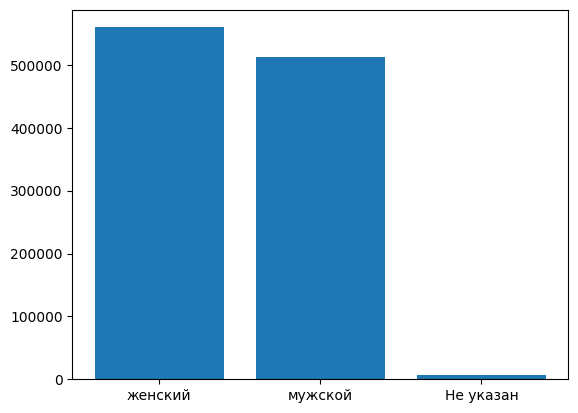

In [14]:
gender_url = "http://127.0.0.1:2137/count_sort/gender"

gender_response = requests.get(gender_url)

if response.status_code == 200:
    gender_data = gender_response.json()
else:
    gender_data = {}

print(gender_data)

plt.bar([i["name"] for i in gender_data], [i["count"] for i in gender_data])
plt.show()

[{'name': 'до 18 лет', 'count': 41434}, {'name': 'Не указан', 'count': 7234}, {'name': 'от 18 до 24 лет', 'count': 117818}, {'name': 'от 25 до 34 лет', 'count': 227295}, {'name': 'от 35 до 44 лет', 'count': 194612}, {'name': 'от 45 до 54 лет', 'count': 173907}, {'name': 'от 55 до 63 лет', 'count': 165517}, {'name': 'свыше 64 лет', 'count': 151360}]


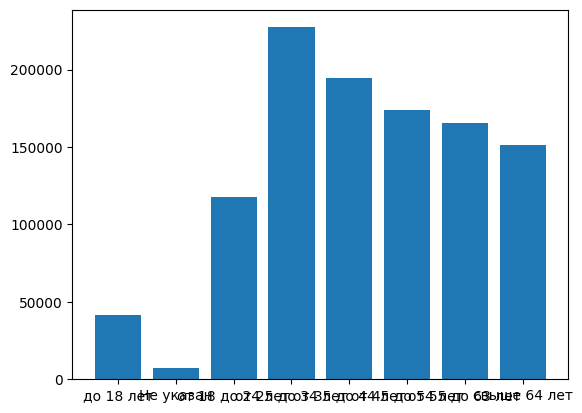

In [15]:
age_url = "http://127.0.0.1:2137/count_sort/tourist_age"

age_response = requests.get(age_url)

if response.status_code == 200:
    age_data = age_response.json()
else:
    age_data = {}

print(age_data)

plt.bar([i["name"] for i in age_data], [i["count"] for i in age_data])
plt.show()

5. Каков средний чек посещения в целом и в разрезе по месяцам.

In [21]:
avg_values_url = "http://127.0.0.1:2137/avg_values"

avg_values_response = requests.get(avg_values_url)

if response.status_code == 200:
    avg_values_data = avg_values_response.json()
else:
    avg_values_data = {}

print(avg_values_data[0]["avg_spent"]*1000000)

48409.908648398465


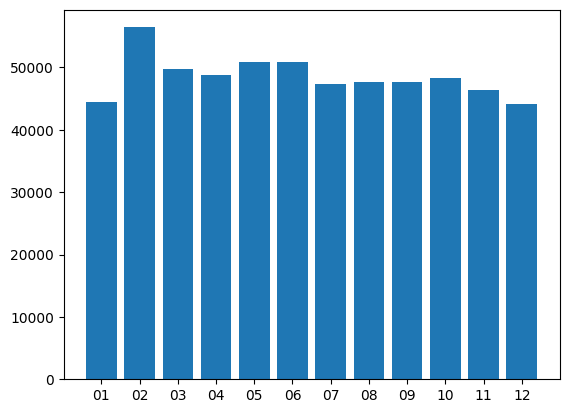

In [24]:
months_url = "http://127.0.0.1:2137/count_sort/month"

months_response = requests.get(months_url)

if response.status_code == 200:
    months_data = months_response.json()
else:
    months_data = {}

plt.bar([i["name"][5:] for i in data], [i["average"] for i in data])
plt.show()

6. Как распределены суммарные траты по регионам.

In [25]:
home_region_url = "http://127.0.0.1:2137/cohort_geo/home_region"

home_region_response = requests.get(home_region_url)

if home_region_response.status_code == 200:
    home_region_data = home_region_response.json()
else:
    home_region_data = {}

print(home_region_data)

[{'name': 'Алтайский край', 'avg_days_cnt': 4.73444976076555, 'avg_visitors_cnt': 4.523923444976076, 'avg_spent': 0.03458254523923445}, {'name': 'Амурская область', 'avg_days_cnt': 5.846698113207547, 'avg_visitors_cnt': 4.495283018867925, 'avg_spent': 0.06799686341981132}, {'name': 'Архангельская область', 'avg_days_cnt': 4.089076884797213, 'avg_visitors_cnt': 3.950734013436178, 'avg_spent': 0.042833455342124904}, {'name': 'Астраханская область', 'avg_days_cnt': 5.022970903522205, 'avg_visitors_cnt': 3.409647779479326, 'avg_spent': 0.04334384614088821}, {'name': 'Белгородская область', 'avg_days_cnt': 4.823264781491003, 'avg_visitors_cnt': 5.591259640102828, 'avg_spent': 0.053224846728791776}, {'name': 'Брянская область', 'avg_days_cnt': 4.159090909090909, 'avg_visitors_cnt': 4.945247933884297, 'avg_spent': 0.04729878902892562}, {'name': 'Владимирская область', 'avg_days_cnt': 4.8238141335914815, 'avg_visitors_cnt': 7.309777347531462, 'avg_spent': 0.04272858328089706}, {'name': 'Волгог

In [31]:
for i in range(len(home_region_data)):
    if home_region_data[i]["name"]=="Не указан":
        home_region_data.pop(i)

df = {"name": [i["name"] for i in home_region_data], "avg_spent": [i["avg_spent"] for i in home_region_data]}

# Координаты регионов (получены из интернета)
df['lat'] = [52.8, 53.8, 64.5, 46.3, 50.6, 53.2, 56.1, 48.7, 59.2, 51.7, 55.75, 59.93, 48.8, 52.0, 57.0, 52.3, 43.5, 54.7, 54.5, 53.9, 43.8, 54.8, 58.6, 58.6, 45.0, 59.9, 55.5, 51.7, 60.1, 52.6, 59.6, 55.8, 68.0, 67.6, 56.3, 58.5, 55.0, 54.9, 51.8, 52.9, 53.2, 58.0, 45.3, 57.8, 44.6, 50.9, 54.7, 51.8, 42.9, 43.2, 46.3, 63.9, 64.0, 56.6, 54.2, 62.0, 43.0, 55.8, 51.7, 53.7, 47.9, 54.6, 53.2, 51.5, 50.9, 56.8, 54.8, 45.0, 52.7, 57.0, 56.5, 54.2, 57.2, 57.3, 54.3, 48.5, 61.0, 55.2, 43.3, 55.5, 66.0, 67.0, 57.6]

df['lon'] = [82.9, 127.7, 40.5, 48.0, 36.6, 34.4, 40.4, 44.5, 39.9, 39.2, 37.62, 30.31, 132.9, 113.5, 41.0, 104.3, 43.6, 20.5, 36.3, 158.6, 41.9, 87.2, 49.7, 41.0, 39.0, 91.7, 64.9, 36.2, 31.6, 39.6, 150.8, 37.8, 33.1, 53.2, 44.0, 31.3, 82.9, 73.4, 55.1, 36.1, 45.0, 56.3, 134.0, 28.3, 40.1, 86.9, 56.0, 107.5, 47.5, 44.9, 44.3, 34.0, 54.0, 47.9, 44.5, 129.8, 44.7, 49.0, 94.4, 91.4, 41.4, 39.7, 50.2, 46.0, 142.7, 60.6, 32.1, 43.0, 41.4, 35.0, 84.9, 37.6, 65.5, 53.2, 48.4, 135.1, 69.0, 61.4, 45.7, 47.1, -169.0, 76.0, 39.8]

#Степенные преобразования для нормального отображения данных
df['deg_count'] = [i["avg_spent"] for i in home_region_data]
df = pd.DataFrame(df)

fig = px.scatter_mapbox(
    df, lat='lat', lon='lon',
    size='deg_count', size_max=25,
    hover_name='name',
    hover_data={'avg_spent': ':.0f', 'lat': False, 'lon': False, 'deg_count': ':.4f'},
    mapbox_style='carto-positron',
    zoom=3
)
fig.show()

C:\Users\Andrzej\AppData\Local\Temp\ipykernel_10544\233157386.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
